# 03 — Event Characterization

## Objective

Characterize the temporal properties of a single flare event by estimating the
local background flux, identifying the flare onset time per energy band, and
locating the SXR peak time. These quantities are the direct inputs to fluence
integration and qf calculation.

## Inputs

- Processed STIX flare catalog (`stix_flare_catalog_sep20_25_2021.csv`)
- STIX Data Center — via `stixdcpy`

## Outputs

- `bg` — per-band background mean and σ, with provenance (pre/post/pre+post)
- `result["t0"]` — flare onset time per energy band
- `result["tp"]` — SXR peak time (anchor for qf)
- `result["flux_subtracted"]` — background-subtracted light curve

## Scientific Milestone

Reproduce the temporal characterization scheme of Awasthi et al. (2021) Section 3.1
on a single test flare: local background estimation, 1σ onset detection, and SXR
peak identification. These three quantities gate everything downstream.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from flare_pipeline.lightcurves import get_lightcurve, parse_lightcurve, extract_flare_window
from flare_pipeline.flare import estimate_background, find_onset_peak

## 1. Load Catalog

In [2]:
flare_df = pd.read_csv("../data/processed/stix_flare_catalog_sep20_25_2021.csv")

flare_df["flare_id"] = flare_df["flare_id"].astype(str)
flare_df["start_UTC"] = pd.to_datetime(flare_df["start_UTC"])
flare_df["end_UTC"] = pd.to_datetime(flare_df["end_UTC"])
flare_df["peak_UTC"] = pd.to_datetime(flare_df["peak_UTC"])

## 2. Select Test Flare

In [3]:
flare_row = flare_df.loc[50]
flare_row[["flare_id", "start_UTC", "peak_UTC", "end_UTC", "GOES_class", "duration"]]

flare_id                      2109241944
start_UTC     2021-09-24 19:43:44.265000
peak_UTC      2021-09-24 19:44:24.265000
end_UTC       2021-09-24 19:46:36.265000
GOES_class                          B1.7
duration                             172
Name: 50, dtype: object

## 3. Fetch Light Curve

A 10-minute pad on each side ensures both background windows (5 min pre/post)
fall within the fetched data.

In [4]:
pad = pd.Timedelta(minutes = 10)

lc = get_lightcurve(
    start_time = (flare_row["start_UTC"] - pad).isoformat(),
    end_time = (flare_row["end_UTC"] + pad).isoformat(),
)

lightcurve = parse_lightcurve(lc)
lightcurve.head()

,time,4_10,10_15,15_25,25_50,50_84
0,2021-09-24 19:22:20,215,53,67,799,431
1,2021-09-24 19:22:24,247,53,67,863,431
2,2021-09-24 19:22:28,247,57,61,799,463
3,2021-09-24 19:22:32,271,41,61,863,431
4,2021-09-24 19:22:36,247,37,75,863,431


## 4. Background Estimation

The 5-minute windows immediately before and after the flare are used to estimate the quiet-Sun background level per energy band. Each window is accepted only if no other cataloged flare overlaps it - contaminated windows are discarded.
The `source` field records which window(s) contributed.

In [5]:
bg = estimate_background(lightcurve, flare_df, flare_row)
bg

{'4_10': {'mean': np.float64(250.78666666666666),
  'std': 18.390465382970515,
  'source': 'pre+post'},
 '10_15': {'mean': np.float64(48.36666666666667),
  'std': 7.200313813693127,
  'source': 'pre+post'},
 '15_25': {'mean': np.float64(64.08),
  'std': 8.858712012673735,
  'source': 'pre+post'},
 '25_50': {'mean': np.float64(816.0666666666667),
  'std': 31.165862124585598,
  'source': 'pre+post'},
 '50_84': {'mean': np.float64(442.3066666666667),
  'std': 21.661194283963344,
  'source': 'pre+post'}}

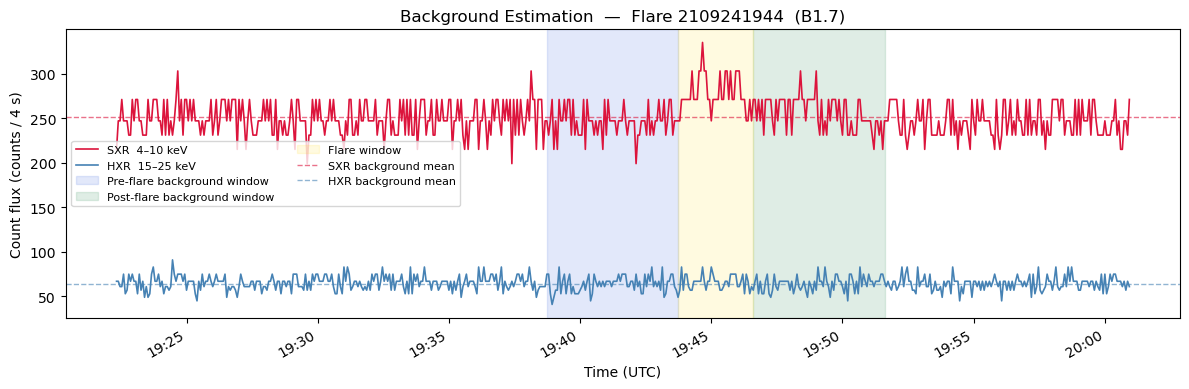

In [6]:
# Reconstruct background window bounds for visualization
# (mirrors the logic inside estimate_background)

bg_pad = pd.Timedelta(minutes = 5)
pre_start  = flare_row["start_UTC"] - bg_pad
pre_end    = flare_row["start_UTC"]
post_start = flare_row["end_UTC"]
post_end   = flare_row["end_UTC"] + bg_pad

fig, ax = plt.subplots(figsize=(12, 4))

ax.plot(lightcurve["time"], lightcurve["4_10"],
        color="crimson", lw=1.2, label="SXR  4–10 keV")
ax.plot(lightcurve["time"], lightcurve["15_25"],
        color="steelblue", lw=1.2, label="HXR  15–25 keV")

# Background windows
ax.axvspan(pre_start,  pre_end,   alpha=0.15, color="royalblue", label="Pre-flare background window")
ax.axvspan(post_start, post_end,  alpha=0.15, color="seagreen",  label="Post-flare background window")

# Flare window
ax.axvspan(flare_row["start_UTC"], flare_row["end_UTC"],
           alpha=0.12, color="gold", label="Flare window")

# Background mean levels
ax.axhline(bg["4_10"]["mean"],  color="crimson",  lw=1, ls="--", alpha=0.6, label="SXR background mean")
ax.axhline(bg["15_25"]["mean"], color="steelblue", lw=1, ls="--", alpha=0.6, label="HXR background mean")

ax.set_xlabel("Time (UTC)")
ax.set_ylabel("Count flux (counts / 4 s)")
ax.set_title(f"Background Estimation  —  Flare {flare_row['flare_id']}  ({flare_row['GOES_class']})")
ax.legend(fontsize=8, ncol=2)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 5. Extract Flare Window and Detect Onset / Peak

The flare window is trimmed from the full light curve.
Background subtraction is then applied per band, and:

- **t0** (onset time): first moment the background-subtracted flux exceeds 1σ
- **tp** (peak time): time of maximum SXR flux — the anchor for qf

In [7]:
flare_window = extract_flare_window(
    lightcurve,
    flare_row["start_UTC"],
    flare_row["end_UTC"],
)

result = find_onset_peak(flare_window, bg)

print(f"tp (SXR peak) : {result['tp']}")
print()
print("t0 per band:")
for band, t in result["t0"].items():
    print(f"  {band} : {t}")

tp (SXR peak) : 2021-09-24 19:44:40

t0 per band:
  4_10 : 2021-09-24 19:43:52
  10_15 : 2021-09-24 19:43:56
  15_25 : 2021-09-24 19:43:52
  25_50 : 2021-09-24 19:43:56
  50_84 : None


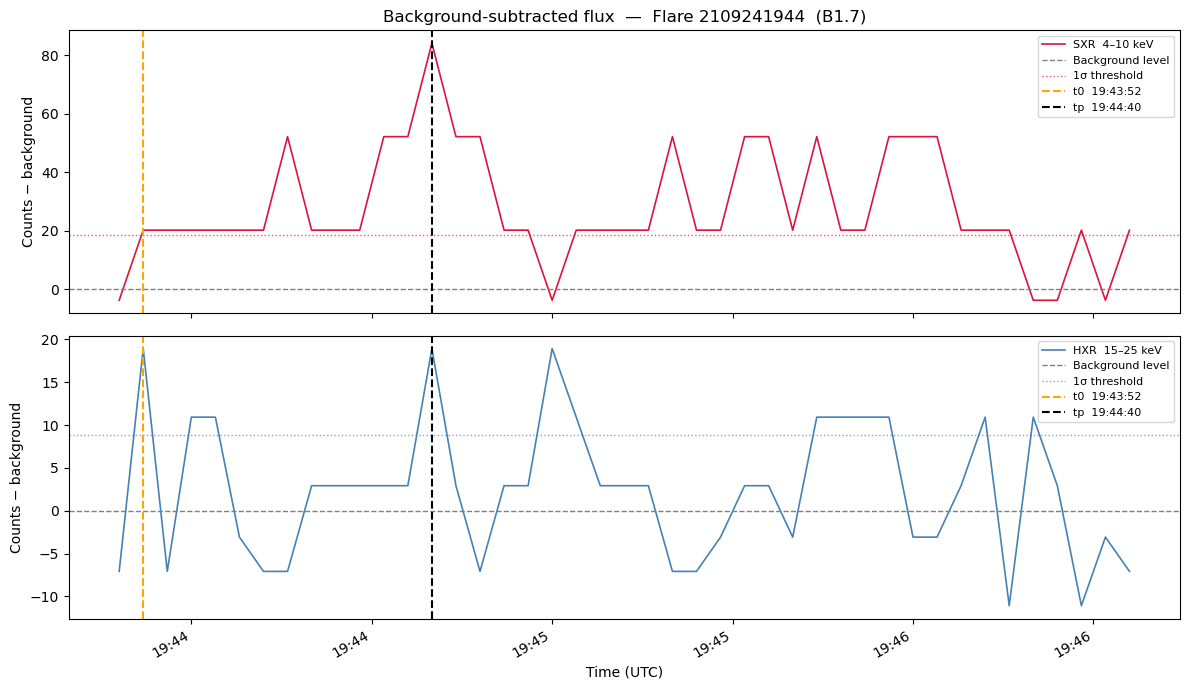

In [8]:
flux_sub = result["flux_subtracted"]

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 7), sharex=True)

# --- Panel 1: SXR ---
ax1.plot(flux_sub["time"], flux_sub["4_10"], color="crimson", lw=1.2, label="SXR  4–10 keV")
ax1.axhline(0,                     color="gray",   lw=1,   ls="--", label="Background level")
ax1.axhline(bg["4_10"]["std"],     color="crimson", lw=1,  ls=":",  alpha=0.7, label="1σ threshold")

if result["t0"]["4_10"]:
    ax1.axvline(result["t0"]["4_10"], color="orange", lw=1.5, ls="--", label=f"t0  {result['t0']['4_10'].strftime('%H:%M:%S')}")
ax1.axvline(result["tp"],           color="black",  lw=1.5, ls="--", label=f"tp  {result['tp'].strftime('%H:%M:%S')}")

ax1.set_ylabel("Counts − background")
ax1.set_title(f"Background-subtracted flux  —  Flare {flare_row['flare_id']}  ({flare_row['GOES_class']})")
ax1.legend(fontsize=8)

# --- Panel 2: HXR ---
ax2.plot(flux_sub["time"], flux_sub["15_25"], color="steelblue", lw=1.2, label="HXR  15–25 keV")
ax2.axhline(0,                      color="gray",     lw=1,  ls="--", label="Background level")
ax2.axhline(bg["15_25"]["std"],     color="steelblue", lw=1, ls=":",  alpha=0.7, label="1σ threshold")

if result["t0"]["15_25"]:
    ax2.axvline(result["t0"]["15_25"], color="orange", lw=1.5, ls="--", label=f"t0  {result['t0']['15_25'].strftime('%H:%M:%S')}")
ax2.axvline(result["tp"],            color="black",   lw=1.5, ls="--", label=f"tp  {result['tp'].strftime('%H:%M:%S')}")

ax2.set_xlabel("Time (UTC)")
ax2.set_ylabel("Counts − background")
ax2.legend(fontsize=8)
ax2.xaxis.set_major_formatter(mdates.DateFormatter("%H:%M"))

fig.autofmt_xdate()
plt.tight_layout()
plt.show()